In [4]:

# basic packages
import pandas as pd
import numpy as np
import datetime as dt
from pytz import timezone
import urllib
import os
import math
from scipy import stats
from scipy.signal import find_peaks, spectrogram

# packages for visualizations
import matplotlib.dates as mdates

from matplotlib import pyplot as plt


Capacity profiles were issued alongside group definitions which set out the maximum current that each group of chargers could draw for each half hour, weekday and weekend.  Further details are given in Section 6.4 of the Final Customer Trial Report.  The method used to derive these capacity profiles is set out in Appendix 1 of the final report.

The format of the capacity profiles was the same for CrowdCharge and GreenFlux.  The fields used were:

-   ProfileID: name of the profile
-   GroupID: the ID of the group to which it applied.  The chargers which made up these groups can be found in the 'Group Definitions'
-   ProfileStartDate: the date/time the profile became active
-   ProfileEndDate: the date/time the profile became inactive
-   DCSProvider: CrowdCharge or GreenFlux
-   Day: Weekday or Weekend
-   HHPeriod: a number between 1 and 48.  The way in which CrowdCharge and GreenFlux applied the HH periods differed during British Summer Time.  Further details are given on Page 102 of the final report.
-   Demand Limit: the maximum current that a group of chargers could draw in the half hour, in Amps.


In [5]:
ev_load = './cleansed_data_EV/GreenFlux3Minute.csv'

df=pd.read_csv(ev_load)



df

,ChargerID,GroupID,TimeStamp,AdjustedTimeStamp,MaxAmpsUsed,AmpsAllocated,TransactionID
0,UK-GFX-ENA0073,GF0008,2018-01-10 16:00:00.000,2018-01-10 16:00:00.000,0.0,13.0,27273.0
1,UK-GFX-ENA0008,GF0012,2018-03-26 22:53:00.000,2018-03-26 23:53:00.000,16.2,16.0,41206.0
2,UK-GFX-ENA0014,GFAppPilot02,2018-04-25 07:14:00.000,2018-04-25 08:14:00.000,0.0,13.0,45654.0
3,UK-GFX-ENA0119,GF0010,2018-02-05 01:12:00.000,2018-02-05 01:12:00.000,0.0,13.0,31455.0
4,UK-GFX-ENA0142,GF0010,2018-02-06 07:53:00.000,2018-02-06 07:53:00.000,0.0,13.0,32043.0
...,...,...,...,...,...,...,...
16696921,UK-GFX-ENA0179,GF0012,2018-03-08 01:07:00.000,2018-03-08 01:07:00.000,0.0,32.0,37344.0
16696922,UK-GFX-ENA0266,Does not exist,2018-08-22 19:45:00.000,2018-08-22 20:45:00.000,0.0,32.0,NaN
16696923,UK-GFX-ENA0055,Does not exist,2017-07-16 10:39:00.000,2017-07-16 11:39:00.000,31.6,32.0,NaN
16696924,UK-GFX-ENA0231,GF0012,2018-03-11 07:18:00.000,2018-03-11 07:18:00.000,0.0,32.0,38300.0


In [6]:
# Load your dataframe (assuming it's called df)
# If not already done:
df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])  # Ensure proper datetime format

# Sort by ChargerID and TimeStamp
df_sorted = df.sort_values(by=["ChargerID", "TimeStamp"]).reset_index(drop=True)

# Display the first few sorted rows
print(df_sorted.head())

        ChargerID         GroupID           TimeStamp  \
0  UK-GFX-ENA0001  Does not exist 2017-03-16 21:40:00   
1  UK-GFX-ENA0001  Does not exist 2017-03-16 21:43:00   
2  UK-GFX-ENA0001  Does not exist 2017-03-16 21:46:00   
3  UK-GFX-ENA0001  Does not exist 2017-03-16 21:49:00   
4  UK-GFX-ENA0001  Does not exist 2017-03-16 21:52:00   

         AdjustedTimeStamp  MaxAmpsUsed  AmpsAllocated  TransactionID  
0  2017-03-16 21:40:00.000          0.0           16.0          353.0  
1  2017-03-16 21:43:00.000         30.7           32.0          353.0  
2  2017-03-16 21:46:00.000         30.8           32.0          353.0  
3  2017-03-16 21:49:00.000         31.1           32.0          353.0  
4  2017-03-16 21:52:00.000         30.8           32.0          353.0  


In [7]:
df_sorted

,ChargerID,GroupID,TimeStamp,AdjustedTimeStamp,MaxAmpsUsed,AmpsAllocated,TransactionID
0,UK-GFX-ENA0001,Does not exist,2017-03-16 21:40:00,2017-03-16 21:40:00.000,0.0,16.0,353.0
1,UK-GFX-ENA0001,Does not exist,2017-03-16 21:43:00,2017-03-16 21:43:00.000,30.7,32.0,353.0
2,UK-GFX-ENA0001,Does not exist,2017-03-16 21:46:00,2017-03-16 21:46:00.000,30.8,32.0,353.0
3,UK-GFX-ENA0001,Does not exist,2017-03-16 21:49:00,2017-03-16 21:49:00.000,31.1,32.0,353.0
4,UK-GFX-ENA0001,Does not exist,2017-03-16 21:52:00,2017-03-16 21:52:00.000,30.8,32.0,353.0
...,...,...,...,...,...,...,...
16696921,UK-GFX-ENA0348,GFTariffsPilot02,2018-12-16 23:47:00,2018-12-16 23:47:00.000,15.6,16.0,84711.0
16696922,UK-GFX-ENA0348,GFTariffsPilot02,2018-12-16 23:50:00,2018-12-16 23:50:00.000,15.6,16.0,84711.0
16696923,UK-GFX-ENA0348,GFTariffsPilot02,2018-12-16 23:53:00,2018-12-16 23:53:00.000,15.6,16.0,84711.0
16696924,UK-GFX-ENA0348,GFTariffsPilot02,2018-12-16 23:56:00,2018-12-16 23:56:00.000,15.6,16.0,84711.0


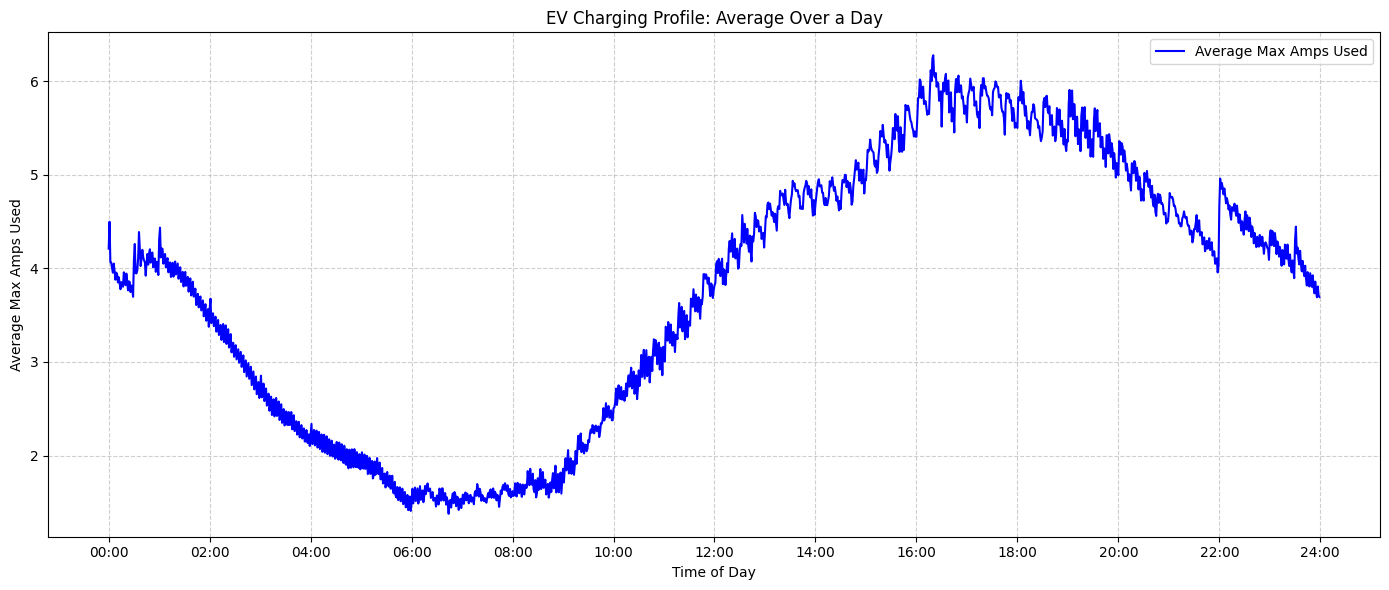

In [8]:

# Ensure TimeStamp is in datetime format
df_sorted["TimeStamp"] = pd.to_datetime(df_sorted["TimeStamp"])

# Create a 'MinutesSinceMidnight' column
df_sorted["MinutesSinceMidnight"] = df_sorted["TimeStamp"].dt.hour * 60 + df_sorted["TimeStamp"].dt.minute

# Group by each minute of the day and calculate average MaxAmpsUsed
df_avg_day = df_sorted.groupby("MinutesSinceMidnight")["MaxAmpsUsed"].mean().reset_index()

# Convert minutes back to HH:MM format for nicer x-axis labels
df_avg_day["TimeOfDay"] = pd.to_datetime(df_avg_day["MinutesSinceMidnight"], unit="m").dt.strftime("%H:%M")

# Plot the average charging profile
plt.figure(figsize=(14, 6))
plt.plot(df_avg_day["MinutesSinceMidnight"], df_avg_day["MaxAmpsUsed"], color="blue", label="Average Max Amps Used")

# Formatting
plt.xlabel("Time of Day")
plt.ylabel("Average Max Amps Used")
plt.title("EV Charging Profile: Average Over a Day")
plt.xticks(
    ticks=range(0, 1441, 120),
    labels=[f"{h:02d}:00" for h in range(0, 25, 2)]
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Show plot
plt.show()


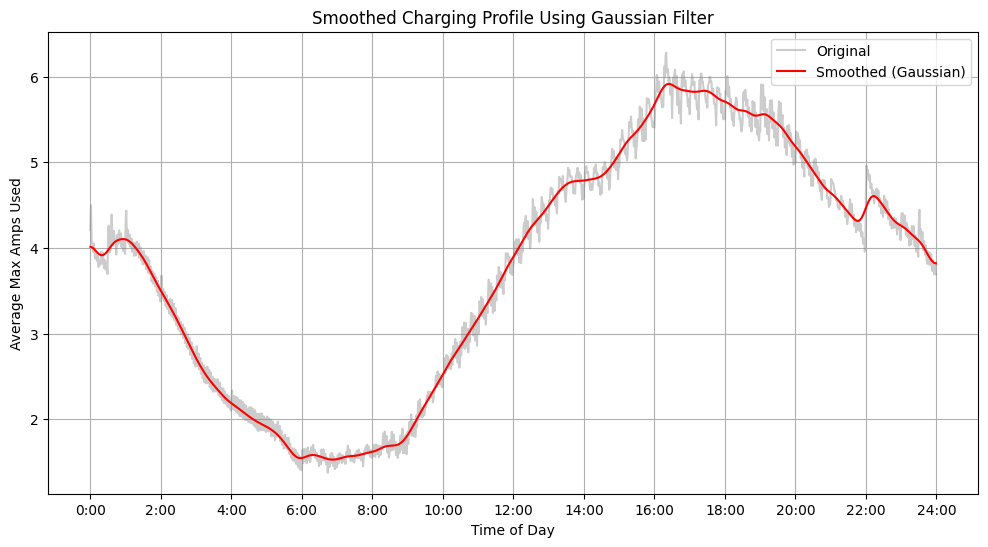

In [9]:
from scipy.ndimage import gaussian_filter1d

# Apply Gaussian filter
df_avg_day["Smoothed"] = gaussian_filter1d(df_avg_day["MaxAmpsUsed"], sigma=10)  # Adjust sigma for smoothness

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_avg_day["MinutesSinceMidnight"], df_avg_day["MaxAmpsUsed"], alpha=0.4, label="Original", color="gray")
plt.plot(df_avg_day["MinutesSinceMidnight"], df_avg_day["Smoothed"], label="Smoothed (Gaussian)", color="r")

# Formatting
plt.xlabel("Time of Day")
plt.ylabel("Average Max Amps Used")
plt.title("Smoothed Charging Profile Using Gaussian Filter")
plt.legend()
plt.xticks(
    ticks=range(0, 1441, 120),
    labels=[f"{h}:00" for h in range(0, 25, 2)]
)
plt.grid(True)
plt.show()


In [10]:
def assign_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Other"

# Convert timestamp and assign season
df_sorted["TimeStamp"] = pd.to_datetime(df_sorted["TimeStamp"])
df_sorted["Season"] = df_sorted["TimeStamp"].apply(assign_season)


In [11]:
# Create wide-format load profile DataFrames
summer_profiles = []
winter_profiles = []

for charger_id, profiles in charger_profiles.items():
    summer = profiles["Summer"]
    winter = profiles["Winter"]

    summer_row = summer.reindex([f"{h:02d}:00" for h in range(24)], fill_value=0)
    winter_row = winter.reindex([f"{h:02d}:00" for h in range(24)], fill_value=0)

    summer_profiles.append([charger_id] + summer_row.tolist())
    winter_profiles.append([charger_id] + winter_row.tolist())

# Create DataFrames
columns = ["ChargerID"] + [f"{h:02d}:00" for h in range(24)]
df_summer_profiles = pd.DataFrame(summer_profiles, columns=columns)
df_winter_profiles = pd.DataFrame(winter_profiles, columns=columns)


NameError: name 'charger_profiles' is not defined

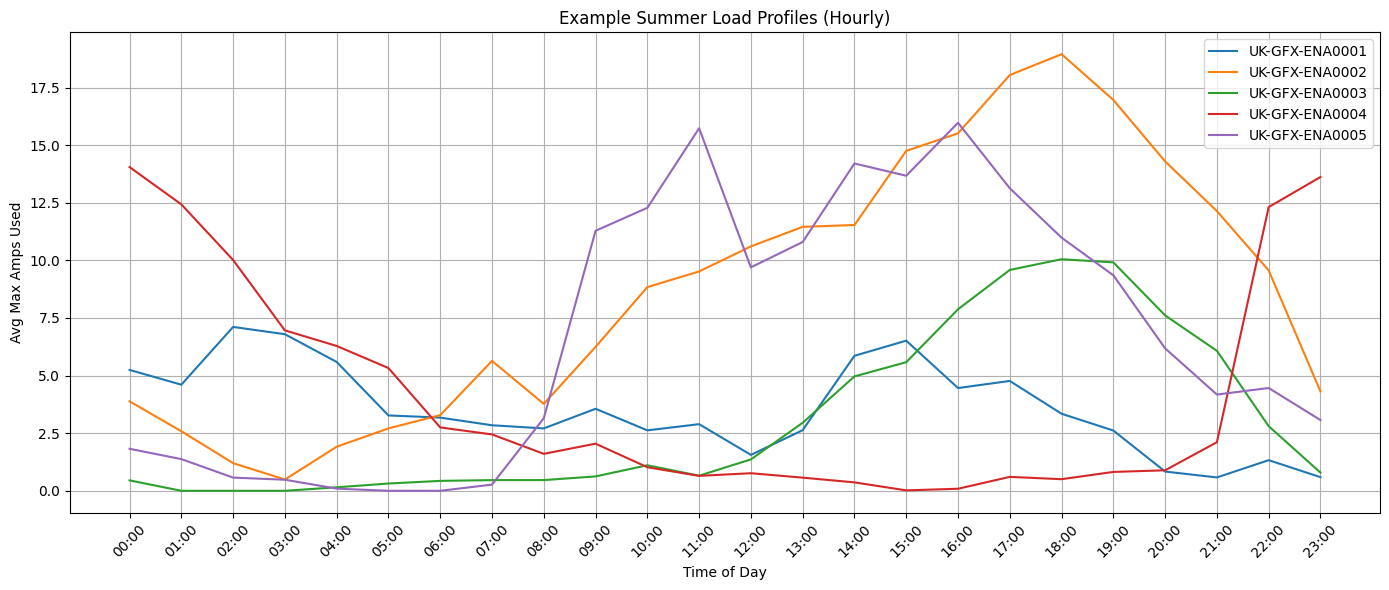

In [ ]:
# Plot a few charger load profiles (Summer)
df_to_plot = df_summer_profiles.set_index("ChargerID").head(5).T  # transpose for plotting

plt.figure(figsize=(14, 6))
for charger in df_to_plot.columns:
    plt.plot(df_to_plot.index, df_to_plot[charger], label=charger)

plt.title("Example Summer Load Profiles (Hourly)")
plt.xlabel("Time of Day")
plt.ylabel("Avg Max Amps Used")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


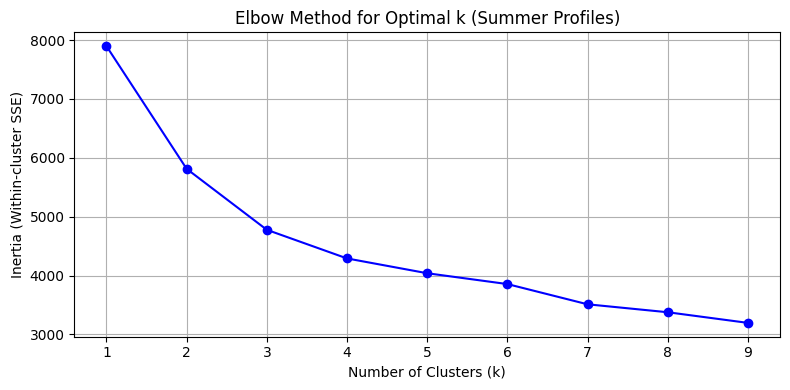

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- Step 1: Prepare the Data ---
# Only time columns (hours) for clustering
time_columns = [col for col in df_summer_profiles.columns if col not in ["ChargerID", "Cluster"]]
X = df_summer_profiles[time_columns].values

# Normalize profiles (optional but recommended for shape-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Step 2: Elbow Method to Determine Optimal Clusters ---
inertia = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method for Optimal k (Summer Profiles)")
plt.grid(True)
plt.xticks(K_range)
plt.tight_layout()
plt.show()


In [ ]:
# --- Step 3: Run KMeans with Optimal k ---
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to DataFrame
df_summer_profiles["Cluster"] = clusters


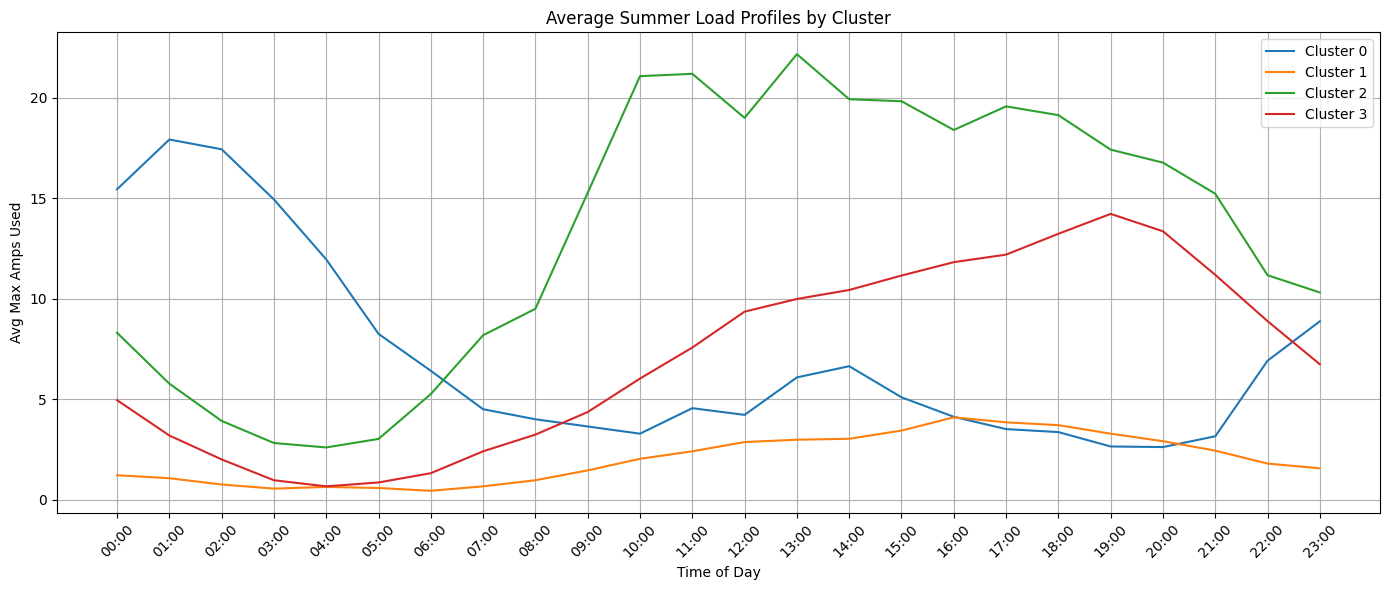

In [ ]:
# --- Step 4: Visualize Average Profile per Cluster ---
plt.figure(figsize=(14, 6))

for cluster_id in sorted(df_summer_profiles["Cluster"].unique()):
    cluster_group = df_summer_profiles[df_summer_profiles["Cluster"] == cluster_id]
    avg_profile = cluster_group[time_columns].mean()

    plt.plot(time_columns, avg_profile, label=f"Cluster {cluster_id}")

plt.title("Average Summer Load Profiles by Cluster")
plt.xlabel("Time of Day")
plt.ylabel("Avg Max Amps Used")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Extract time columns for clustering
time_columns = [col for col in df_winter_profiles.columns if col not in ["ChargerID", "Cluster"]]
X_winter = df_winter_profiles[time_columns].values

# Scale the data
scaler_winter = StandardScaler()
X_winter_scaled = scaler_winter.fit_transform(X_winter)


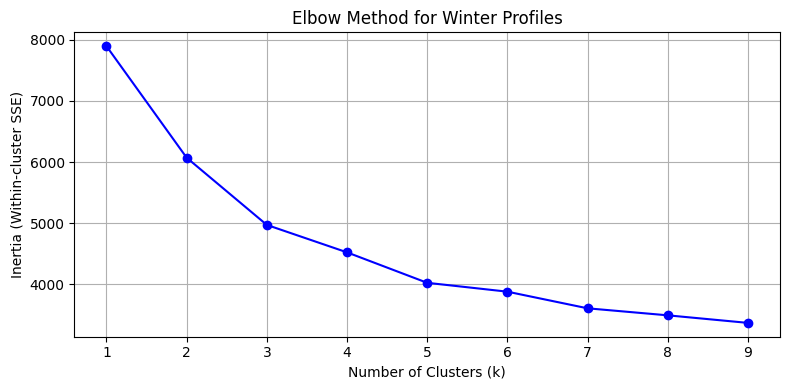

In [ ]:
# Use elbow method to find best k
inertia_winter = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_winter_scaled)
    inertia_winter.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia_winter, 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method for Winter Profiles")
plt.grid(True)
plt.xticks(K_range)
plt.tight_layout()
plt.show()


In [ ]:
optimal_k_winter = 4
kmeans_winter = KMeans(n_clusters=optimal_k_winter, random_state=42)
clusters_winter = kmeans_winter.fit_predict(X_winter_scaled)

# Assign clusters
df_winter_profiles["Cluster"] = clusters_winter


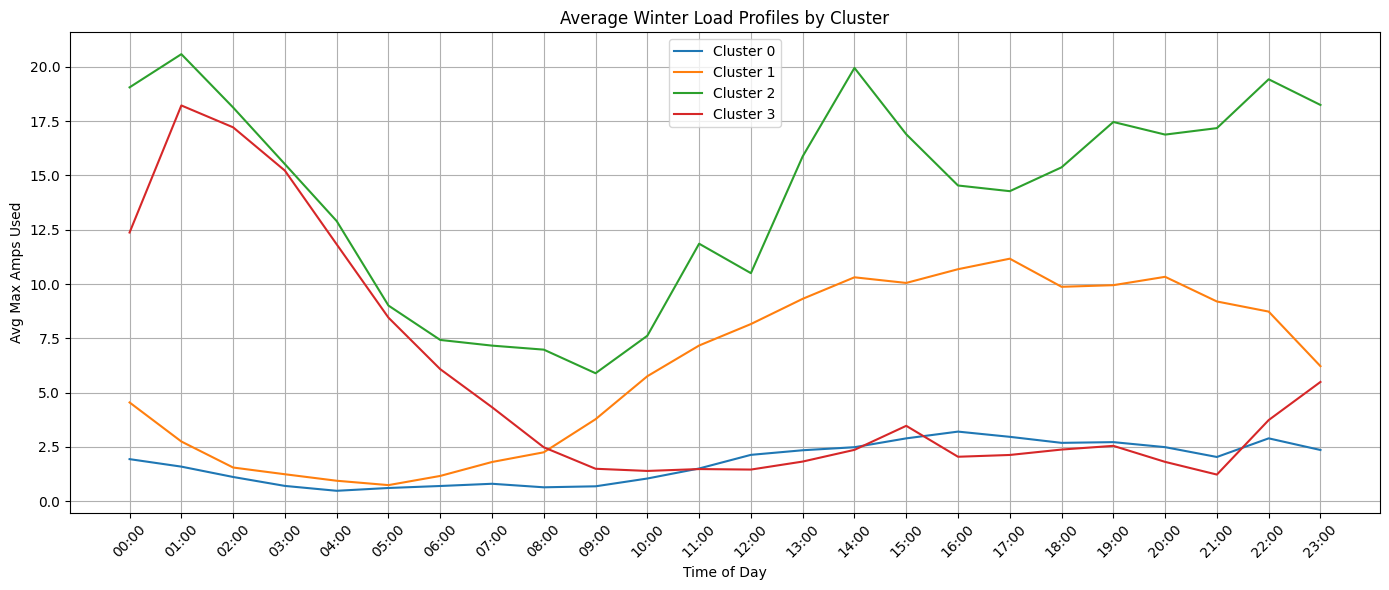

In [ ]:
# Plot average profile per winter cluster
plt.figure(figsize=(14, 6))

for cluster_id in sorted(df_winter_profiles["Cluster"].unique()):
    cluster_group = df_winter_profiles[df_winter_profiles["Cluster"] == cluster_id]
    avg_profile = cluster_group[time_columns].mean()

    plt.plot(time_columns, avg_profile, label=f"Cluster {cluster_id}")

plt.title("Average Winter Load Profiles by Cluster")
plt.xlabel("Time of Day")
plt.ylabel("Avg Max Amps Used")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
